# 00 — Data Discovery

Explore the raw BNPL dataset through the reusable loading and data-quality components provided by `bnpl_credit_risk`.

## 1. Configuration and raw data loading

In [1]:
from bnpl_credit_risk.data.loaders import BNPLDataLoader
from bnpl_credit_risk.data.quality import DataQualityReport
from bnpl_credit_risk.settings import get_settings, load_config

settings = get_settings()
config = load_config()

loader = BNPLDataLoader(settings, config.data)
quality_report = DataQualityReport(
    target_column=config.data.target_column,
    size=config.data.quality_report.visualization.size,
)
df = loader.load_raw()

2026-08-27 17:14:55.235 | INFO     | bnpl_credit_risk.data.loaders:load_raw:37 - Loaded raw dataset path=/Users/surelmanda/3-Mlops-Databricks-Projects/BNPL-Credit-Risk/data/raw/BNPL_CreditRisk_Dataset.csv rows=10345 columns=17


## 2. Dataset overview

Inspect a small sample and the dataset dimensions before computing detailed quality statistics.

In [2]:
display(df.head())

print(f"Rows: {df.shape[0]:,}")
print(f"Columns: {df.shape[1]}")
print(f"Target: {config.data.target_column}")

,user_id,age,employment_type,monthly_income,credit_score,purchase_amount,product_category,bnpl_installments,repayment_delay_days,missed_payments,default_flag,app_usage_frequency,location,transaction_date,debt_to_income_ratio,risk_score,customer_segment
0,1,56,Salaried,68529.50,552,5000.00,Electronics,12,13,1,0,8.49,Australia,2023-06-10,0.072961,165.2,Medium Risk
1,2,19,Student,7247.85,300,1073.23,Fashion,12,13,1,0,3.09,USA,2024-10-07,0.148076,266.0,High Risk
2,3,20,Self-Employed,41582.26,471,5000.00,Electronics,3,19,2,0,3.33,Australia,2023-04-05,0.120244,229.6,High Risk
3,4,21,Salaried,14423.46,300,4076.83,Sports,6,18,5,1,5.86,Germany,2023-06-24,0.282653,356.0,High Risk
4,5,43,Salaried,42845.50,512,5000.00,Electronics,9,0,0,0,7.36,India,2024-10-19,0.116698,135.2,High Risk


Rows: 10,345
Columns: 17
Target: default_flag


## 3. Column-level quality profile

Review data types, missingness, cardinality, zeros, infinite values, numeric outliers, descriptive statistics and representative examples.

In [3]:
column_profile = quality_report.profile_dataset(df)
display(column_profile)

2026-08-27 17:14:55.376 | INFO     | bnpl_credit_risk.data.profiling:inspect:56 - Computing dataset quality summary rows=10345 columns=17


,Column,Type,Non-Null,Missing,% Missing,Cardinality,% Unique,Zeros,% Zeros,Infinite,Outliers,% Outliers,Min,Mean,Median,Max,Std Dev,Examples
0,user_id,int64,10345,0,0.0,10345,100.00,0,0.0,0,0,0.0,1.0,5173.0,5173.0,10345.0,2986.4886,"[1, 2, 3, 4, 5]"
1,age,int64,10345,0,0.0,42,0.41,0,0.0,0,0,0.0,18.0,38.5599,39.0,59.0,12.1318,"[56, 19, 20, 21, 43]"
2,employment_type,object,10345,0,0.0,4,0.04,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,"[Salaried, Student, Self-Employed, Unemployed]"
3,monthly_income,float64,10345,0,0.0,9984,96.51,0,0.0,0,25,0.24,5000.0,35053.3819,23800.52,145767.12,27084.5173,"[68529.5, 7247.85, 41582.26, 14423.46, 42845.5]"
4,credit_score,int64,10345,0,0.0,534,5.16,0,0.0,0,0,0.0,300.0,448.1761,403.0,850.0,136.5183,"[552, 300, 471, 512, 729]"
5,purchase_amount,float64,10345,0,0.0,4011,38.77,0,0.0,0,0,0.0,100.0,3979.4027,5000.0,5000.0,1500.8285,"[5000.0, 1073.23, 4076.83, 1686.24, 3628.68]"
6,product_category,object,10345,0,0.0,5,0.05,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,"[Electronics, Fashion, Sports, Home, Beauty]"
7,bnpl_installments,int64,10345,0,0.0,4,0.04,0,0.0,0,0,0.0,3.0,7.4775,9.0,12.0,3.3629,"[12, 3, 6, 9]"
8,repayment_delay_days,int64,10345,0,0.0,33,0.32,1219,11.78,0,1,0.01,0.0,8.7428,9.0,33.0,6.7818,"[13, 19, 18, 0, 1]"
9,missed_payments,int64,10345,0,0.0,8,0.08,3704,35.8,0,8,0.08,0.0,1.0159,1.0,7.0,0.9967,"[1, 2, 5, 0, 3]"


## 4. Data quality summary

Build the same reusable health report that is available to the project pipelines.

In [4]:
report = quality_report.build(df)

print("DATA QUALITY SUMMARY")
print("-" * 40)
print(f"Rows              : {report['n_rows']:,}")
print(f"Columns           : {report['n_columns']}")
print(f"Duplicate rows    : {report['n_duplicate_rows']:,}")
print(f"Missing values    : {report['n_missing_values_total']:,}")

missing_by_column = report["missing_values_by_column"]
if missing_by_column:
    print("\nMissing values by column:")
    for column, count in missing_by_column.items():
        print(f"  - {column}: {count:,}")
else:
    print("Missing by column : none")

print(f"\nTarget distribution ({config.data.target_column}):")
for target_class, statistics in report.get("target_distribution", {}).items():
    print(
        f"  - Class {target_class}: "
        f"{statistics['count']:,} rows ({statistics['rate']:.1%})"
    )

DATA QUALITY SUMMARY
----------------------------------------
Rows              : 10,345
Columns           : 17
Duplicate rows    : 0
Missing values    : 0
Missing by column : none

Target distribution (default_flag):
  - Class 0: 6,305 rows (60.9%)
  - Class 1: 4,040 rows (39.1%)


## 5. Visual quality summary

Render the consolidated quality dashboard from the same `DataQualityReport` instance.

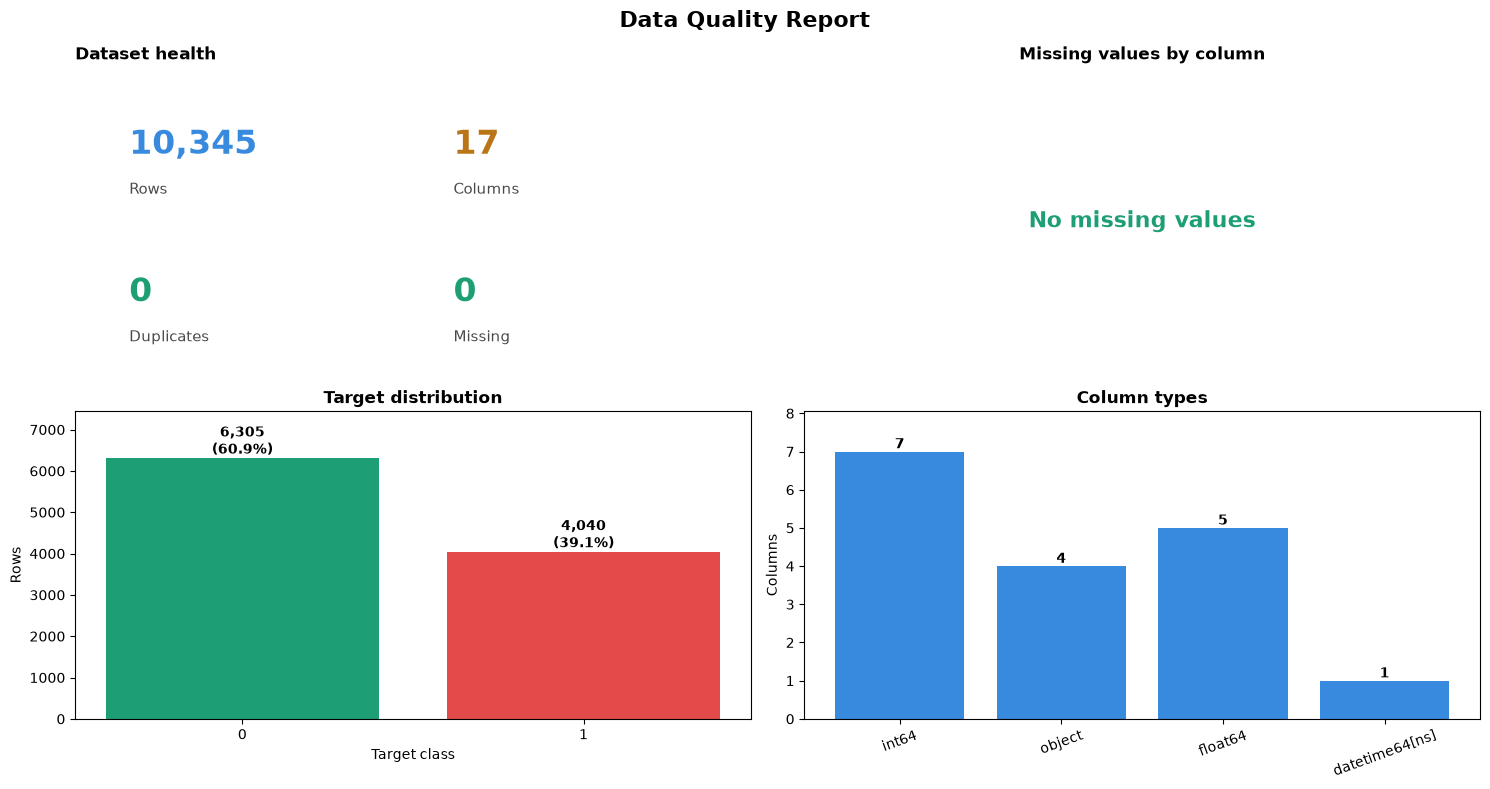

In [5]:
quality_report.show(df)